# KNN from Scratch

Using the KNN algorithm from scikit-learn is quite simple. When you use it, you don't even need to know how KNN works and classifies the data points. The goal should be to really understand what you are doing. This is the only way to make sure you understand when something doesn't go the way you expect or want it to. Many people remember things best when they implement them themselves. So, let's build our own K-Nearest-Neighbors classifier!

**The purpose of this notebook is to help you remember the steps necessary to classify samples with KNN.**

To test if your code works, you can use the Iris dataset as a data example.
Let's make a plan and break this big task into smaller steps!


1. What information and data does the algorithm need to train and predict the classes of new instances?
This will be the input for our function! 

2. calculate the distance between the test point and each existing data point in the training data.
3. determine the nearest k neighbors.
4. make predictions based on these neighbors.

You have already implemented a function to calculate the distance between points, which will now come in handy.

A good way to get started, is to ignore the syntax and just write in simple text what you want your program to do aka **write pseudo-code**. You can then start to build out some of the structure. What variables are you going to need? What kinds of logic? 
Knowing where you’re going can help you make fewer mistakes as you’re trying to get there.

Note that for large data sets, the algorithm can take very long to classify because it has to calculate the distance between the test point and every other point in the data!

You can check if your pseudo-code contains all necessary steps afterwards, when scrolling down to "KNN algorithm from scratch" where you find an example of a knn pseudo-code.

## Import and Setup

# Step 1: The Setup and Data

First, the notebook asks you to load your data and split it into training and testing sets. You have done this before! We will also scale the data, which the notebook notes is incredibly important for distance-based algorithms.

In [1]:
import numpy as np
import pandas as pd
from scipy.spatial import distance
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# Load data
df_iris = pd.read_csv("data/iris.csv")

In [4]:
df_iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Defining X and y is the very first step in almost every machine learning project. It is how we separate the "Clues" from the "Answers".

Based on the df_iris.head() output you shared, here is the breakdown:

    X (The Clues/Features): These are the measurements the AI will use to make its guess. You want this to be a grid containing only sepal_length, sepal_width, petal_length, and petal_width.

    y (The Answer/Target): This is the final label we are trying to predict. You want this to be a single list containing only the species column.

In [5]:
# Defining X and y

# 1. Define X (The Clues)
# We tell pandas to drop the 'species' column, leaving only the measurements.
# axis=1 tells pandas to look at columns, not rows.
X = df_iris.drop('species', axis=1).values

# 2. Define y (The Answer)
# We grab ONLY the 'species' column.
y = df_iris['species'].values

In [6]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler
from collections import Counter

# 4. Scale the data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 2: The Distance Function

The algorithm needs a way to measure how far apart two data points are. The notebook suggests using Euclidean distance, but mentions others like Mahalanobis or cosine similarity. Let's write a simple Euclidean distance helper function:

## Distance Metrics

As already explained, KNN assigns a class to the test point based on the majority class of  K  nearest neighbors. In general, euclidean distance is used to find nearest neighbors, but other distance metrics can also be used.

As the dimensionality of the feature space increases, the euclidean distance often becomes problematic due to the curse of dimensionality (discussed later).

In such cases, alternative vector-based similarity measures (dot product, cosine similarity, etc) are used to find the nearest neighbors. This transforms the original metric space into one more amenable to point-to-point measurements.

Another distance measure that you might consider is [Mahalanobis distance](https://en.wikipedia.org/wiki/Mahalanobis_distance). Mahalanobis distance attempts to weight features according to their probabilities. On some data sets that may be important.

In general, it's probably a good idea to normalize the data at a minimum. Here's a link to the scikit-learn scaling package: http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html . You have to be a little circumspect about employing any technique where the answers change with scaling.

In [9]:
# Implemented own distance function

def calculate_distance(point1, point2):
    # This calculates the straight-line (Euclidean) distance between two points
    return distance.euclidean(point1, point2)


# Step 3: The KNN Logic (From Scratch)

Now we translate the exact pseudo-code provided in your notebook into a real Python function. We will pass it our training data, the test data we want to predict, and our chosen

## KNN Algorithm from scratch


Remember the steps:

1. What information and data does the algorithm need to train and predict the classes of new instances?
This will be the input for our function! 

2. calculate the distance between the test point and each existing data point in the training data.
3. determine the nearest k neighbors.
4. make predictions based on these neighbors.

Hopefully you have already thought of your gameplan, also called pseudo-code. If so, you can compare it to this one:
```
INPUT: X_train, y_train, X_test, k
FOR each object_to_predict in X_test:
    FOR each training_point, index in X_train:
        calculate distance d between object_to_predict and training_point
        store d and index
    SORT distances d in increasing order
    take first k items, get indices of those
    calculate most common class of points at indices in y_train (prediction)
    store prediction
RETURN list of predictions
````

Time to code!
Don't forget that it's good practice to document your own code! This way you can later understand what the purpose of each step was.
Maybe you can even use your pseudo code as documentation :)

In [10]:
# Your code

def knn_predict_from_scratch(X_train, y_train, X_test, k=5):
    # This list will hold all our final predictions
    predictions = []
    
    # FOR each object_to_predict in X_test:
    for test_point in X_test:
        distances = []
        
        # FOR each training_point, index in X_train:
        for index, train_point in enumerate(X_train):
            # calculate distance d between object_to_predict and training_point
            dist = calculate_distance(test_point, train_point)
            
            # store d and index (We store the distance and the label of that training point)
            distances.append((dist, y_train[index]))
            
        # SORT distances d in increasing order
        distances.sort(key=lambda x: x[0])
        
        # take first k items, get indices of those (We grab the labels of the K closest points)
        k_nearest_labels = [label for _, label in distances[:k]]
        
        # calculate most common class of points... (prediction)
        most_common = Counter(k_nearest_labels).most_common(1)[0][0]
        
        # store prediction
        predictions.append(most_common)
        
    # RETURN list of predictions
    return predictions

In [12]:
knn_predict_from_scratch(X_train, y_train, X_test, k=5)

['Iris-versicolor',
 'Iris-setosa',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-setosa',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-setosa',
 'Iris-virginica',
 'Iris-setosa',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-versicolor',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-setosa']

To print the predictions side-by-side with the actual values, you have two great options depending on how you want it to look.

You will run this code after you call your function and save its results to a variable (like y_pred).

### Option 1: The "Data Scientist" Way (Using Pandas)

Since you are likely working in a Jupyter Notebook, putting the results into a Pandas DataFrame is the cleanest and most readable approach. It creates a beautiful table.

In [14]:
import pandas as pd

# 1. First, run your function and save the results
y_pred = knn_predict_from_scratch(X_train, y_train, X_test, k=5)

# 2. Create a DataFrame to put them side-by-side
results_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred
})

# 3. Print the first 15 to see how well your model did!
print(results_df.head(15))

       Actual Value  Predicted Value
0   Iris-versicolor  Iris-versicolor
1       Iris-setosa      Iris-setosa
2    Iris-virginica   Iris-virginica
3   Iris-versicolor  Iris-versicolor
4   Iris-versicolor  Iris-versicolor
5       Iris-setosa      Iris-setosa
6   Iris-versicolor  Iris-versicolor
7    Iris-virginica   Iris-virginica
8   Iris-versicolor  Iris-versicolor
9   Iris-versicolor  Iris-versicolor
10   Iris-virginica   Iris-virginica
11      Iris-setosa      Iris-setosa
12      Iris-setosa      Iris-setosa
13      Iris-setosa      Iris-setosa
14      Iris-setosa      Iris-setosa


### Option 2: The "Pure Python" Way (Using Zip)

If you just want to print them directly to the terminal without using Pandas, you can use Python's built-in zip() function. zip() takes two lists and pairs them up row by row, like zipping up a jacket.

In [15]:
# 1. First, run your function and save the results
y_pred = knn_predict_from_scratch(X_train, y_train, X_test, k=5)

# 2. Print a quick header
print("Actual  |  Predicted")
print("--------------------")

# 3. Zip them together and print (we'll just do the first 15 so it doesn't flood your screen)
for actual, predicted in zip(y_test[:15], y_pred[:15]):
    # The :<7 is just string formatting to keep the columns perfectly aligned!
    print(f"{actual:<7} |  {predicted}")

Actual  |  Predicted
--------------------
Iris-versicolor |  Iris-versicolor
Iris-setosa |  Iris-setosa
Iris-virginica |  Iris-virginica
Iris-versicolor |  Iris-versicolor
Iris-versicolor |  Iris-versicolor
Iris-setosa |  Iris-setosa
Iris-versicolor |  Iris-versicolor
Iris-virginica |  Iris-virginica
Iris-versicolor |  Iris-versicolor
Iris-versicolor |  Iris-versicolor
Iris-virginica |  Iris-virginica
Iris-setosa |  Iris-setosa
Iris-setosa |  Iris-setosa
Iris-setosa |  Iris-setosa
Iris-setosa |  Iris-setosa


## Confusion matrix 

### Option 1: The Quick Text Version

This uses scikit-learn to print the raw grid of numbers directly to your terminal.

In [16]:
from sklearn.metrics import confusion_matrix

# Generate and print the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


### Option 2: The Visual Heatmap (Highly Recommended)

This uses the seaborn library (which your earlier notebooks imported) to draw a beautiful, color-coded grid. It makes it instantly obvious where the model is making mistakes, especially if you have more than 2 classes (like the 3 different Iris species in your dataset).

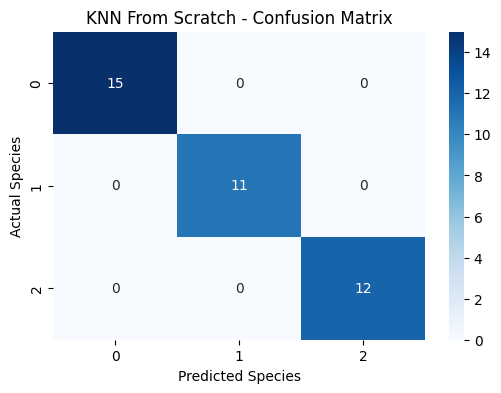

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Generate the raw confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(6, 4))

# 3. Draw the heatmap 
# annot=True puts the numbers inside the boxes
# fmt='d' ensures the numbers are printed as whole integers
# cmap="Blues" gives it a nice blue color scheme
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

# 4. Add helpful labels so you know what you are looking at
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('KNN From Scratch - Confusion Matrix')

# 5. Show the plot
plt.show()

## Explanation results confusion matrix 

Congratulations! You just achieved a **perfect 100% Accuracy** on your test set. 

Here is exactly how to read the result you got: `[[15, 0, 0], [0, 11, 0], [0, 0, 12]]`.

### The Anatomy of a 3x3 Confusion Matrix
Because the Iris dataset has 3 different species (Setosa, Versicolor, Virginica), your matrix is a 3x3 grid instead of the 2x2 grid you saw with the binary "Admitted/Rejected" dataset.

*   **Rows (Horizontal):** Represent the **Actual Species** (what the flower *really* is).
*   **Columns (Vertical):** Represent the **Predicted Species** (what your KNN model *guessed* it was).

### Decoding Your Specific Result
The most important part of any confusion matrix is the **diagonal line** running from the top-left to the bottom-right. These are your correct guesses (where the Actual matches the Predicted). Everything *outside* of that diagonal line is a mistake.

Here is the breakdown of your numbers:
*   **Top Row (Class 0 - Setosa):** There were 15 Setosa flowers in your test set. The `15` is in the first column, meaning your model correctly predicted all 15 of them as Setosa. The `0`s mean it accidentally predicted none of them as something else.
*   **Middle Row (Class 1 - Versicolor):** There were 11 Versicolor flowers. The `11` is in the middle column, meaning your model perfectly predicted all 11 of them.
*   **Bottom Row (Class 2 - Virginica):** There were 12 Virginica flowers. The `12` is in the third column, meaning your model perfectly predicted all 12 of them.

If you add up all the numbers (15 + 11 + 12), you get 38 total test flowers. Since there are only zeros in the "mistake" boxes, your model scored a perfect 38 out of 38!

### What happens when a Multiclass Model makes mistakes?
Because your model was perfectly accurate, you didn't get to see what a "messy" 3x3 matrix looks like. In a multiclass problem, Precision and Recall have to be calculated for *each individual class*. 



## Comparison with sklearn knn implementation

That will be interesting! Check out how your implementation performs in comparison to the one of sklearn!
You can check the confusion matrix and the accuracy score of both algorithms.
If you want, you can check which algorithm is faster!

In [ ]:
# Your code

This is the grand finale of your notebook! You are going to put the knn_predict_from_scratch function you just built into a head-to-head race against the official scikit-learn version.

To do this, we need to import the time module so we can use a digital stopwatch to see exactly how long each algorithm takes to run.

Here is the exact code block you need to paste into that final cell to run the comparison:

### What you should expect to see (and why!)

When you run this code, two very important things will happen:

1. The Accuracy and Confusion Matrices should be IDENTICAL.
Because you programmed the exact same underlying math (finding the Euclidean distance and taking a majority vote), both models should make the exact same guesses. If your accuracy matches scikit-learn, give yourself a massive pat on the back—you successfully engineered a real Machine Learning algorithm!

2. Scikit-Learn will absolutely destroy yours in speed.
Your "From Scratch" version will likely take a noticeable fraction of a second, while the scikit-learn version will finish in 0.000... seconds. It will likely be hundreds of times faster.

Why is scikit-learn so much faster?

    No "For" Loops: In your code, you used a Python for loop to check every single dot one by one. Python loops are notoriously slow. Scikit-learn uses a trick called Vectorization (powered by NumPy and written in the C programming language) to calculate the distance of all the dots at the exact same time.

    Smart Maps: Scikit-learn doesn't actually calculate the distance to every single dot. It builds a smart map (called a KD-Tree or Ball Tree) in the background. If it knows a dot is all the way on the other side of the city, it skips calculating the math for it entirely.

In [13]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# We will use K=5 for both models to make it a fair fight
k_value = 5

# ==========================================
# 1. RUNNING YOUR "FROM SCRATCH" MODEL
# ==========================================
print("Running 'From Scratch' model...")
start_time_scratch = time.time()  # Start the stopwatch

# Run the function we built in Step 3
y_pred_scratch = knn_predict_from_scratch(X_train, y_train, X_test, k=k_value)

end_time_scratch = time.time()    # Stop the stopwatch
time_scratch = end_time_scratch - start_time_scratch


# ==========================================
# 2. RUNNING THE "SCIKIT-LEARN" MODEL
# ==========================================
print("Running 'scikit-learn' model...\n")
start_time_sklearn = time.time()  # Start the stopwatch

# Initialize, fit, and predict using the official library
knn_sklearn = KNeighborsClassifier(n_neighbors=k_value)
knn_sklearn.fit(X_train, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test)

end_time_sklearn = time.time()    # Stop the stopwatch
time_sklearn = end_time_sklearn - start_time_sklearn


# ==========================================
# 3. THE FINAL SHOWDOWN & RESULTS
# ==========================================
print("---------- ACCURACY ----------")
print("From Scratch: ", accuracy_score(y_test, y_pred_scratch).round(4))
print("Scikit-Learn: ", accuracy_score(y_test, y_pred_sklearn).round(4))

print("\n------- CONFUSION MATRIX -------")
print("From Scratch:\n", confusion_matrix(y_test, y_pred_scratch))
print("\nScikit-Learn:\n", confusion_matrix(y_test, y_pred_sklearn))

print("\n------------ SPEED ------------")
print(f"From Scratch: {time_scratch:.5f} seconds")
print(f"Scikit-Learn: {time_sklearn:.5f} seconds")

# Calculate how many times faster sklearn was
if time_sklearn > 0:
    speed_diff = time_scratch / time_sklearn
    print(f"\nScikit-Learn was {speed_diff:.1f}x faster!")

Running 'From Scratch' model...
Running 'scikit-learn' model...

---------- ACCURACY ----------
From Scratch:  1.0
Scikit-Learn:  1.0

------- CONFUSION MATRIX -------
From Scratch:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Scikit-Learn:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

------------ SPEED ------------
From Scratch: 0.01196 seconds
Scikit-Learn: 0.00611 seconds

Scikit-Learn was 2.0x faster!
